En un forward la leaky neuron integra en el tiempo (time steps). A mi me gustaría visualizar el potencial de membrana en el tiempo.

In [ ]:
import torch.nn as nn
import torch
import snntorch as snn
class LeakyNeuronTest(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.neuron = snn.Leaky()

    def forward(self, input_current):


        return input_current

In [33]:
import random
random.seed(0)
torch.use_deterministic_algorithms(True)
torch.manual_seed(1234)
import numpy as np
np.random.seed(0)

In [159]:
n = 2
channels = 200
test_input_current = torch.rand((n,channels))

LC
<KeysViewHDF5 ['SNID', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_2048', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'flux', 'flux_err', 'labels', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'test', 'time', 'time_detection', 'time_photometry', 'training_0', 'validation_0']>
using sampler
LC
<KeysViewHDF5 ['SNID', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_2048', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'flux', 'flux_err', 'labels', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'test', 'time', 'time_detection', 'time_photometry', 'training_0', 'validation_0']>
LC
<KeysViewHDF5 ['SNID', 'extracted_feat_1024', 'extracted_feat_128', 'extracted_feat_16', 'extracted_feat_2048', 'extracted_feat_256', 'extracted_feat_32', 'extracted_feat_512', 'extracted_feat_64', 'flux', 'flux_err', 'labels', '

100%|██████████| 80/80 [00:15<00:00,  5.22it/s]


                precision    recall  f1-score   support

           AGN     0.3500    0.2172    0.2680      3288
           QSO     0.4867    0.4067    0.4431      3428
            EA     0.5405    0.3297    0.4096      3500
           YSO     0.2789    0.1812    0.2197      2715
          SNIa     0.3183    0.0775    0.1246      1639
       CV/Nova     0.3116    0.3513    0.3302      1617
          RRLc     0.3221    0.3350    0.3284      3439
         RSCVn     0.3408    0.4251    0.3783      2522
        Blazar     0.1518    0.1298    0.1399      1364
          SNII     0.1992    0.0623    0.0950       802
         EB/EW     0.2994    0.3433    0.3198      3635
           LPV     0.5694    0.6300    0.5982      3319
           CEP     0.4536    0.3354    0.3857      2871
         RRLab     0.3812    0.3599    0.3702      3507
Periodic-Other     0.2191    0.3558    0.2712       742
          DSCT     0.4367    0.5480    0.4860      1604
         SNIbc     0.0660    0.1917    0.0982  

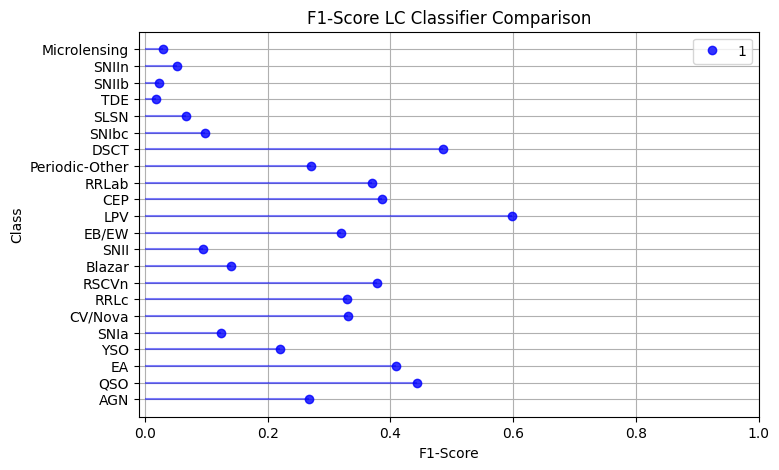

In [ ]:

from torchmetrics import Accuracy, F1Score, ConfusionMatrix
from ReportPretraining import QuickLoader
import torch
import torch.nn as nn
# imports
import snntorch as snn
from snntorch import surrogate

import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
# imports
import snntorch as snn
from snntorch import surrogate
from src.augmentations import LightCurveTransform as LC

# pytorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.transforms import RandomChoice, RandomApply,RandomAdjustSharpness,RandomSolarize
 

class SpikeLayer(nn.Module):
    def __init__(self, input_size,hidden_size, output_size,spike_grad, beta, kernel_size = 1):
        assert hidden_size % kernel_size == 0, '{} % {} != 0'.format(hidden_size,kernel_size)
        assert isinstance(kernel_size, int)
        super().__init__()
        self.kernel_size = kernel_size
        self.linear = nn.Linear(input_size, hidden_size) # takes an input of 3197 and outputs 128
        self.lif = snn.Leaky(beta=torch.rand(hidden_size),
                               threshold = 1.0,
                               learn_beta=True,
                               learn_threshold = True, 
                               learn_graded_spikes_factor = True,
                               spike_grad=spike_grad)
        self.lif2 = snn.Leaky(beta=torch.rand(output_size),
                               threshold = 1.0,
                               learn_beta=True,
                               learn_threshold = True, 
                               learn_graded_spikes_factor = True,
                               spike_grad=spike_grad)
        #self.lif = snn.Synaptic(alpha=alpha, beta=beta)
        self.out = nn.Linear(hidden_size//kernel_size, output_size)
        self.dropout = nn.Dropout(0.0)
        
    def forward(self, x):
        mem1 = self.lif.init_leaky()
        mem2 = self.lif2.init_leaky()
        cur1 = F.max_pool1d(self.dropout(self.linear(x)), self.kernel_size)
        spk1, mem1 = self.lif(cur1, mem1) 
        cur2 = self.dropout(self.out(spk1))
        #print(mem1.shape)
        spk2, mem2 = self.lif2(cur2, mem2) 

        return spk2.view(x.size(0),-1)
   

class Eye(nn.Module):
    def __init__(self, input_size, 
                 hidden_size, 
                 output_size,
                spike_grad,
                beta):
        super().__init__()
        self.spike = SpikeLayer(input_size = input_size,
                    hidden_size = hidden_size,
                    output_size = output_size,
                    spike_grad=spike_grad,
                     beta =beta)
        self.ln = nn.LayerNorm(input_size)
    def forward(self, x):
        return self.spike(self.ln(x))


class ANGEL(nn.Module):
    def __init__(self, num_bands = 2, 
                    input_size = 200,
                    hidden_size = 5000,
                    output_size = 200, 
                    beta = None,
                    spike_grad = None,
                    num_classes = 22):
        super().__init__()

        self.bands = nn.ModuleList([Eye(input_size,
                                        hidden_size,
                                        output_size,
                                        spike_grad = spike_grad,
                                         beta=torch.rand(hidden_size), 
                                         ) for _ in range(2)])
        self.ln_out = nn.LayerNorm(output_size*num_bands)
        self.classifier = SpikeLayer(output_size*num_bands, 
                                     hidden_size= hidden_size,
                                     spike_grad=spike_grad,
                                     beta = torch.rand(hidden_size),
                                     output_size=num_classes,
                                     )
        self.classifier = nn.Linear(output_size*num_bands,num_classes)
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_normal_(p)

    def forward(self,x):
        outs = []
        for i in range(x.size(-1)):
            outs.append(self.bands[i](x[:,:,i]))
        outs = torch.concat(outs, axis = -1)
        x = outs
        x = self.ln_out(x)
        x = self.classifier(x)
        return x
    # shape of outs should be [(bsz,spikeout),[bsz, spikeout]]
 
tr = [
       
                    LC.GaussianNoise(num_bands=2, std = 1e-5),
                                   
                    RandomChoice([ LC.GaussianFilter(num_bands=2,filter_std = 0.05),
                                    LC.GaussianFilter(num_bands=2,filter_std = 0.01),
                                   LC.GaussianFilter(num_bands=2,filter_std = 0.1),
                                     ]),
                   
                    LC.CutFirstN(2,mask_first= [-1,0,1,2,4,8,16,32,64,128]),

                    LC.GaussianNoise(num_bands=2, std = 1e-5),
       
                    RandomChoice([ LC.GaussianFilter(num_bands=2,filter_std = 0.05),
                                    LC.GaussianFilter(num_bands=2,filter_std = 0.01),
                                   LC.GaussianFilter(num_bands=2,filter_std = 0.1), 
                                     ]),
                   
                    LC.CutFirstN(2,mask_first= [-1,0,1,2,4,8,16,32,64,128])
      ]
p_ = 0.5
tr = [RandomApply([t], p = p_) for t in tr]
ql = QuickLoader(batch_size=512, transforms = tr, train_apply_transform=True, use_sampler=True)
train_dataloader = ql.train
validation_dataloader = ql.validation

def test_model(set_type):
    device = 'cuda:0'
    model = ANGEL(2, spike_grad=None)
    model.to(device)
    model.to('cpu')
    model.load_state_dict(torch.load('best_model.pth'))
    model.eval()
    
    # Initialize confusion matrix for final evaluation
    from torchmetrics.classification import MulticlassConfusionMatrix
    confusion = MulticlassConfusionMatrix(num_classes=22)
    f1_metric = F1Score(task="multiclass", num_classes=22, average='macro')
    
    with torch.no_grad():
        if set_type == 'validation':
            all_preds = []
            all_labels = []
            
            for data in tqdm(validation_dataloader):
                inputs = data['data'].float().to('cpu')
                
                labels = data['labels'].long().to('cpu')
                
                outputs = model(inputs)
                predictions = torch.argmax(outputs, dim=1)
                
                all_preds.append(predictions)
                all_labels.append(labels)
            
            # Concatenate all batches
            all_preds = torch.cat(all_preds)
            all_labels = torch.cat(all_labels)
            from src.utils.data.AlerceDictionaries import ZTF_TAXONOMY
            print(classification_report(all_labels, all_preds, digits = 4, target_names=ZTF_TAXONOMY().keys()))
            
            d1 = classification_report(all_labels, all_preds, digits = 4, target_names=ZTF_TAXONOMY().keys(), output_dict=True)
            f1_baseline = []
            import matplotlib.pyplot as plt
            import pandas as pd
            fig,ax = plt.subplots(1,1,figsize = (8,5))
            for key,value in d1.items():
                if key in ZTF_TAXONOMY().keys():
                
                    f1_baseline.append(value['f1-score'])
                
            df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
            ordered_df_1 = df_1 #.sort_values(by='values')
            my_range_1=range(1,len(df_1.index)+1)
 
            plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
             
            plt.legend(['1','2'])
            
            # The horizontal plot is made using the hline function
            plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
            
            # The horizontal plot is made using the hline function
            

            # Add titles and axis names
            plt.yticks(my_range_1, ordered_df_1['group'])
            plt.title(f"F1-Score LC Classifier Comparison", loc='center')

            plt.xlabel('F1-Score')
            plt.ylabel('Class')
            plt.xlim(-0.01,1)
            #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
            plt.grid('on', )

            #plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})'])
            # Show the plot
            plt.show()
            return all_preds, all_labels
        if set_type == 'test':
            all_preds = []
            all_labels = []
            for data in tqdm(ql.test):
                    inputs = data['data'].float().to('cpu')
                    labels = data['labels'].long().to('cpu')
                    
                    outputs = model(inputs)
                    predictions = torch.argmax(outputs, dim=1)
                    
                    all_preds.append(predictions)
                    all_labels.append(labels)
                
            # Concatenate all batches
            all_preds = torch.cat(all_preds)
            all_labels = torch.cat(all_labels)
            from src.utils.data.AlerceDictionaries import ZTF_TAXONOMY
            print(classification_report(all_labels, all_preds, digits = 4, target_names=ZTF_TAXONOMY().keys()))
            d1 = classification_report(all_labels, all_preds, digits = 4, target_names=ZTF_TAXONOMY().keys(), output_dict=True)
            f1_baseline = []
            f1_finetune = []
            import matplotlib.pyplot as plt
            import pandas as pd
            fig,ax = plt.subplots(1,1,figsize = (8,5))
            for key,value in d1.items():
                print(key,value)
                if key in ZTF_TAXONOMY().keys():
                
                    f1_baseline.append(value['f1-score'])
                
            df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
            ordered_df_1 = df_1 #.sort_values(by='values')
            my_range_1=range(1,len(df_1.index)+1)
 
            plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
             
            plt.legend(['1','2'])
            
            # The horizontal plot is made using the hline function
            plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
            
            # The horizontal plot is made using the hline function
            

            # Add titles and axis names
            plt.yticks(my_range_1, ordered_df_1['group'])
            plt.title(f"F1-Score LC Classifier Comparison", loc='center')

            plt.xlabel('F1-Score')
            plt.ylabel('Class')
            plt.xlim(-0.01,1)
            #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
            plt.grid('on', )

            plt.legend(f"baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})")
            # Show the plot
            plt.show()
            return all_preds, all_labels

preds, target = test_model('validation')

In [84]:
def get_confusion_matrix(preds,target, title = ''):
        from src.utils.plots.ATATConfusionMatrix import elasticc_confusion_matrix
        from sklearn.metrics import classification_report
        import matplotlib.pyplot as plt
        from src.utils.data.AlerceDictionaries import ZTF_TAXONOMY

        order_classes = ['SNIa', # yes
                 'SNIbc', # yes
                 'SNIIb', # yes
                 'SNII', # yes
                 'SNIIn', # yes
                 'SLSN', # yes
                 'TDE', # yes
                 'Microlensing', # yes
                 'QSO', 
                 'AGN', # yes
                 'Blazar', 
                 'YSO', 
                 'CV/Nova', 
                 'LPV', 
                 'EA', 
                 'EB/EW', # yes
                 'Periodic-Other', 
                 'RSCVn', 
                 'CEP', 
                 'RRLab', 
                 'RRLc', 
                 'DSCT']
        from sklearn.metrics import confusion_matrix
        import matplotlib.pyplot as plt

        fs = 11
        y_true = [ZTF_TAXONOMY.values_as_keys()[i] for i in np.array(target).astype(int)]
        y_pred = [ZTF_TAXONOMY.values_as_keys()[i] for i in np.array(preds).astype(int)]

        cm = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=order_classes, normalize='true')
        np.set_printoptions(precision=4, suppress=True)
        cmap = plt.cm.Blues
        fig, ax = plt.subplots(figsize=(11, 11)) #, dpi=110)
        decimals = 2
        im = ax.imshow(np.around(cm, decimals=decimals), interpolation='nearest', cmap=cmap)
        # color map
        new_color = cmap(1.0) 

        # Añadiendo manualmente las anotaciones con la media y desviación estándar
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                if cm[i, j] >= 0.005:
                    #print(cm[i, j])
                    text = f'{np.around(cm[i, j], decimals=decimals)}'
                    color = "white" if cm[i, j] > 0.5 else new_color  # Blanco para la diagonal, tono de azul para otras celdas
                    ax.text(j, i, text, ha="center", va="center", color=color, fontsize=fs)
                else:
                    text = f'{np.around(cm[i, j], decimals=decimals)}'
                    color = "white" if cm[i, j] > 0.5 else new_color  # Blanco para la diagonal, tono de azul para otras celdas
                    ax.text(j, i, text, ha="center", va="center", color=color, fontsize=fs)

        # Ajustes finales y mostrar la gráfica
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.set_xticks(np.arange(len(order_classes)))
        ax.set_yticks(np.arange(len(order_classes)))
        ax.set_xticklabels(order_classes)
        ax.set_yticklabels(order_classes)
        plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

        ax.set_title('ATAT ', fontsize=16, pad=13)
        ax.set_xlabel('Predicted label', fontsize=16, labelpad=13)  # Label del eje x
        ax.set_ylabel('True label', fontsize=16, labelpad=13)        # Label del eje y


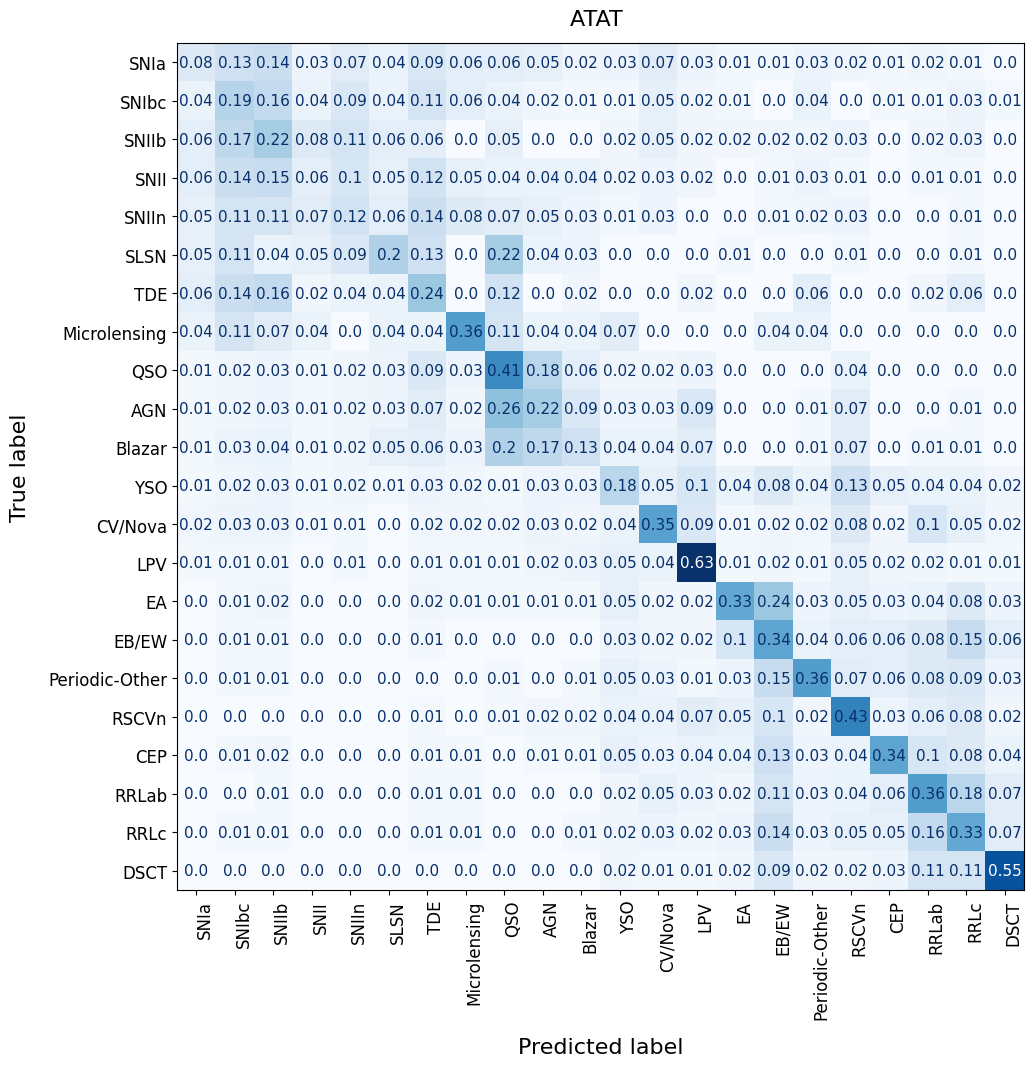

In [85]:
get_confusion_matrix(preds, target)

In [86]:
asdfadsf

NameError: name 'asdfadsf' is not defined

In [ ]:
class SpikeViz:
    def __init__(self):
        self.neuron_model_1 = snn.Leaky(beta = 0.999,
                                      threshold=0.1)
        self.neuron_model_2 = snn.Leaky(beta = 0.1,
                                      threshold=0.1)
        self.linear = nn.Linear(channels, channels)
        self.membrane_1_save = torch.empty((n,channels))
        self.membrane_2_save = torch.empty((n,channels))


    def __call__(self, current:list):
        membrane_potential_1 = self.neuron_model_1.init_leaky()
        membrane_potential_2 = self.neuron_model_2.init_leaky()

        spikes_1, membrane_potential_1 = self.neuron_model_1(current,membrane_potential_1 )
        new_current = self.linear(spikes_1)
        spikes_2, membrane_potential_2 = self.neuron_model_2(new_current, membrane_potential_2)
        return spikes_1, membrane_potential_1,spikes_2, membrane_potential_2
    

    

In [ ]:
test = SpikeViz()

<Axes: >

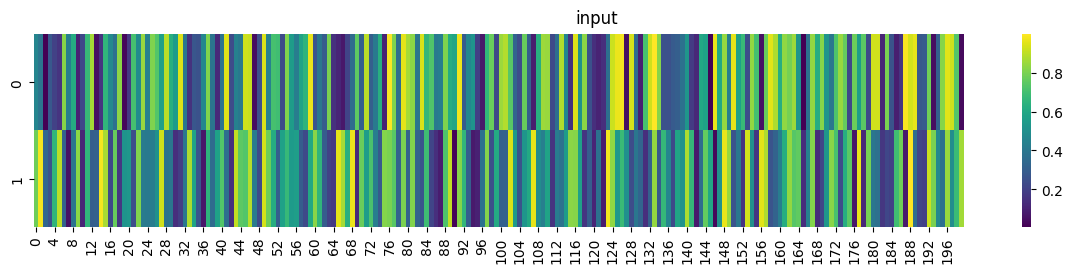

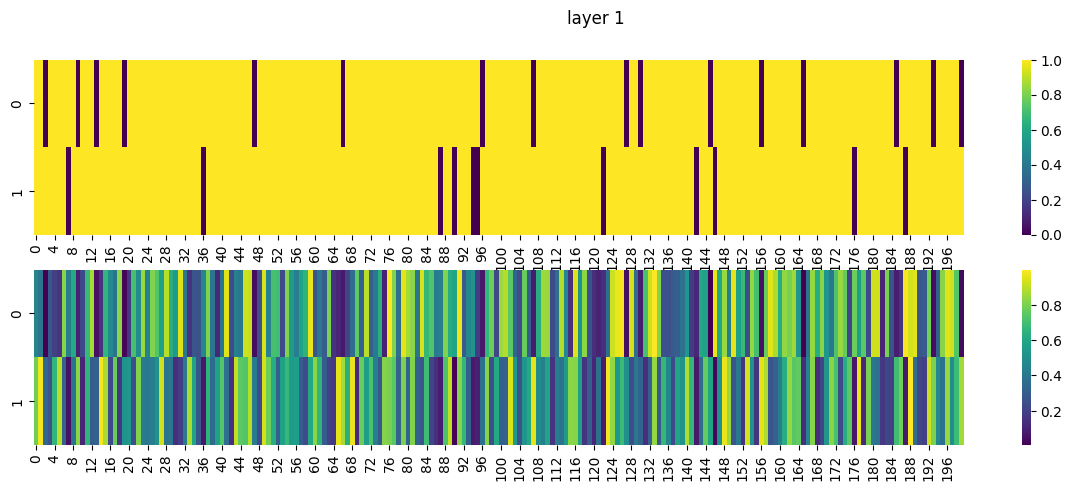

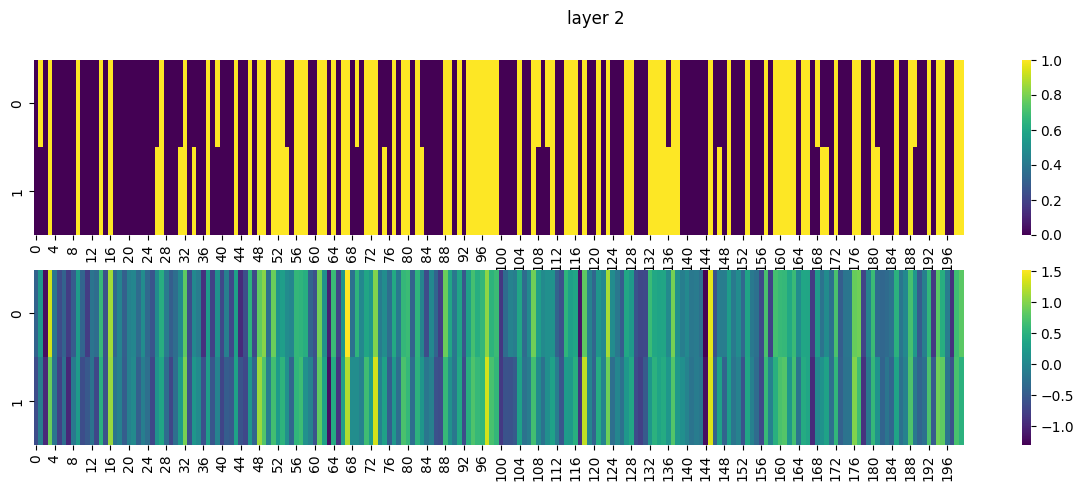

In [ ]:

import seaborn as sns
output = test(test_input_current)
spikes1, mem1,spikes2, mem2 = (i.detach().numpy() for i in output)
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (15,2.5))
sns.heatmap(test_input_current,cmap = 'viridis',ax = fig.add_subplot(111, ))
fig.suptitle('input')

fig = plt.figure(figsize = (15,5))
sns.heatmap(spikes1,cmap = 'viridis',ax = fig.add_subplot(211, ))
sns.heatmap(mem1,cmap = 'viridis',ax = fig.add_subplot(212, ))
fig.suptitle('layer 1')

fig = plt.figure(figsize = (15,5))
fig.suptitle('layer 2')
sns.heatmap(spikes2,cmap = 'viridis',ax = fig.add_subplot(211, ))
sns.heatmap(mem2,cmap = 'viridis',ax = fig.add_subplot(212, ))

In [ ]:
from spikemodel import ANGEL
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from ReportPretraining import QuickLoader
import torch
ql = QuickLoader(batch_size=128)

validation_dataloader = ql.validation
model = ANGEL(200) # initialize the model to the new class.
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
device = 'cuda:2'
model.to(device = device)
with torch.no_grad():
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_predicted = []
    all_probs = []
    for data in tqdm(validation_dataloader):
        #print(data.keys())
        inputs, labels =data['data'][:,:,0].float().to(device = device), data['labels'].long().to(device = device)  # Float
        outputs = model(inputs)
        predicted = torch.argmax(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())
        softmax = torch.nn.Softmax(dim=1)
        probabilities = softmax(outputs)[:, 1]  # Assuming 1 represents the positive class
        all_probs.extend(probabilities.cpu().numpy())
    avg_val_loss = test_loss/ len(validation_dataloader)
print(classification_report(all_labels, all_predicted, zero_division = 1, digits = 4))
model.to(device =  'cpu')

LC
using sampler
LC
LC


/tmp/ipykernel_2569915/3533644657.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


RuntimeError: Error(s) in loading state_dict for ANGEL:
	size mismatch for ln_out.weight: copying a param with shape torch.Size([400]) from checkpoint, the shape in current model is torch.Size([40000]).
	size mismatch for ln_out.bias: copying a param with shape torch.Size([400]) from checkpoint, the shape in current model is torch.Size([40000]).
	size mismatch for classifier.weight: copying a param with shape torch.Size([22, 400]) from checkpoint, the shape in current model is torch.Size([22, 40000]).